In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
df = pd.read_csv("/Users/kusumithakatamreddy/Documents/StudentProject/prediction.csv")
df = df.replace('?', pd.NA)
cols = ['2022-23 - Release','2023-24 - Release','2024-25 - Release']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df[cols] = df[cols].fillna(0)
years = [[2022],[2023],[2024]]
df

,Sl. No,State/UT,Category,2022-23 - Release,2023-24 - Release,2024-25 - Release,2025-26 predicted
0,1,Andhra Pradesh,State,45.79,86.33,43.18,<NA>
1,2,Arunachal Pradesh,State,9.34,58.16,8.14,<NA>
2,3,Assam,State,170.16,236.85,52.54,<NA>
3,4,Bihar,State,0.00,48.42,39.35,<NA>
4,5,Chhatisgarh,State,40.42,41.63,20.84,<NA>
5,6,Goa,State,4.45,0.95,2.23,<NA>
6,7,Gujarat,State,65.16,59.21,37.48,<NA>
7,8,Haryana,State,28.84,28.86,0.00,<NA>
8,9,Himachal Pradesh,State,0.00,3.66,3.66,<NA>
9,10,Jammu and Kashmir,State,0.00,0.00,0.00,<NA>


In [4]:
cols = ['2022-23 - Release','2023-24 - Release','2024-25 - Release']
# Remove all-zero rows
df = df[~((df[cols] == 0).all(axis=1))]
# Remove total rows
df = df[~df['State/UT'].str.contains('Total', case=False, na=False)]

In [8]:
df = df.reset_index(drop=True)
df

,Sl. No,State/UT,Category,2022-23 - Release,2023-24 - Release,2024-25 - Release,2025-26 predicted
0,1,Andhra Pradesh,State,45.79,86.33,43.18,<NA>
1,2,Arunachal Pradesh,State,9.34,58.16,8.14,<NA>
2,3,Assam,State,170.16,236.85,52.54,<NA>
3,4,Bihar,State,0.00,48.42,39.35,<NA>
4,5,Chhatisgarh,State,40.42,41.63,20.84,<NA>
5,6,Goa,State,4.45,0.95,2.23,<NA>
6,7,Gujarat,State,65.16,59.21,37.48,<NA>
7,8,Haryana,State,28.84,28.86,0.00,<NA>
8,9,Himachal Pradesh,State,0.00,3.66,3.66,<NA>
9,11,Jharkhand,State,0.00,7.39,18.00,<NA>


In [16]:
for col in cols:
    median_value = df[col].replace(0, pd.NA).median()
    df[col] = df[col].replace(0, median_value)
df

,Sl. No,State/UT,Category,2022-23 - Release,2023-24 - Release,2024-25 - Release,2025-26 predicted
0,1,Andhra Pradesh,State,45.79,86.33,43.18,55.8240
1,2,Arunachal Pradesh,State,9.34,58.16,8.14,22.7058
2,3,Assam,State,170.16,236.85,52.54,111.8709
3,4,Bihar,State,32.99,48.42,39.35,40.0128
4,5,Chhatisgarh,State,40.42,41.63,20.84,27.8481
5,6,Goa,State,4.45,0.95,2.23,1.9698
6,7,Gujarat,State,65.16,59.21,37.48,45.1657
7,8,Haryana,State,28.84,28.86,24.95,9.8114
8,9,Himachal Pradesh,State,32.99,3.66,3.66,3.4770
9,11,Jharkhand,State,32.99,7.39,18.00,14.0231


In [26]:
df[['2022-23 - Release','2023-24 - Release','2024-25 - Release']] = \
df[['2022-23 - Release','2023-24 - Release','2024-25 - Release']].apply(pd.to_numeric, errors='coerce')
print(values)

[45.79, 86.33, 43.18]


In [28]:
from sklearn.ensemble import RandomForestRegressor
cols = ['2022-23 - Release','2023-24 - Release','2024-25 - Release']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
years = [[2022], [2023], [2024]]
predictions = []
for index, row in df.iterrows():
    values = [
        float(row['2022-23 - Release']),
        float(row['2023-24 - Release']),
        float(row['2024-25 - Release'])
    ]
    # Skip if any NaN
    if any(pd.isna(values)):
        predictions.append(None)
        continue
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(years, values)
    pred = model.predict([[2025]])
    predictions.append(pred[0])
df['2025-26 predicted'] = predictions
print(df[['State/UT','2025-26 predicted']])

                      State/UT  2025-26 predicted
0               Andhra Pradesh            55.8240
1            Arunachal Pradesh            22.7058
2                        Assam           111.8709
3                        Bihar            41.6623
4                  Chhatisgarh            27.8481
5                          Goa             1.9698
6                      Gujarat            45.1657
7                      Haryana            26.2784
8             Himachal Pradesh             5.1265
9                    Jharkhand            15.6726
10                   Karnataka            67.5004
11                      Kerala            10.5858
12              Madhya Pradesh            38.1443
13                 Maharashtra            58.3084
14                     Manipur            25.2894
15                   Meghalaya            23.9049
16                     Mizoram            11.3046
17                    Nagaland            30.8695
18                      Odisha            32.9879


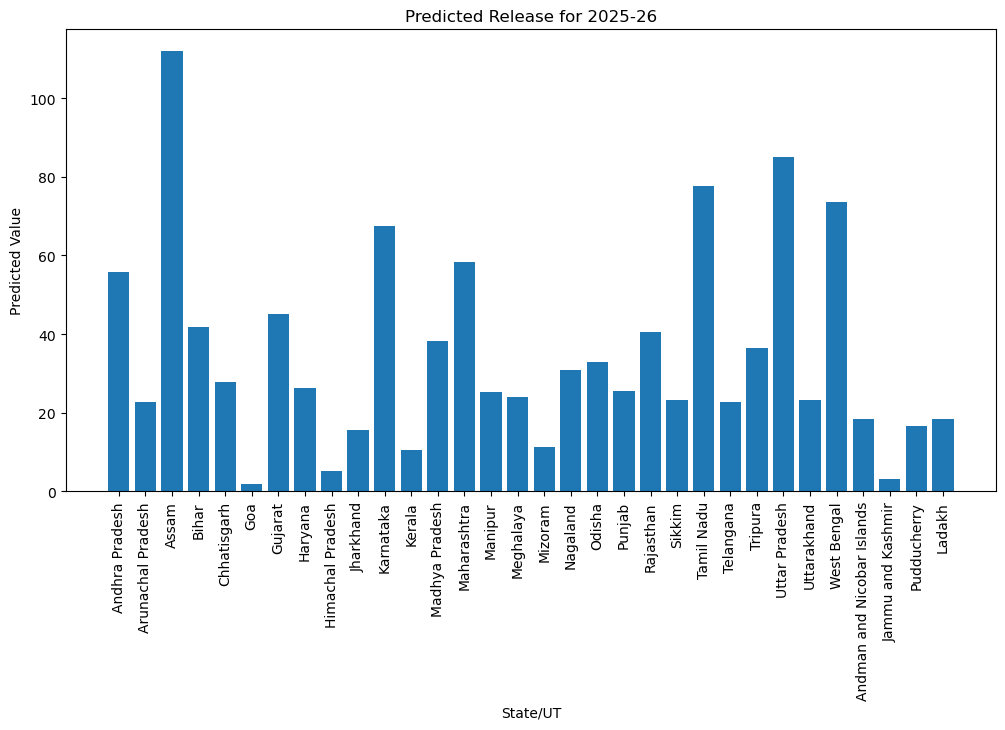

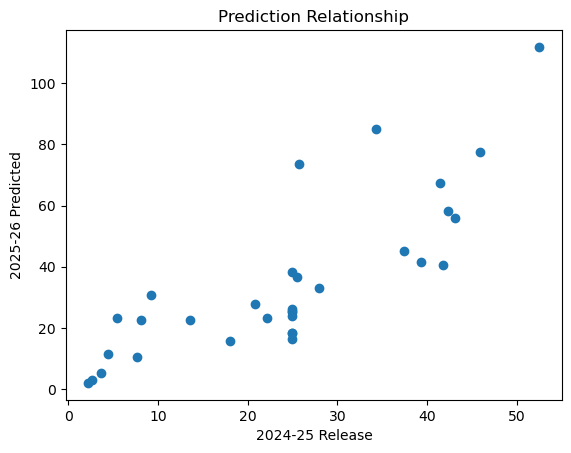

In [30]:
import matplotlib.pyplot as plt
state = "Andhra Pradesh"
row = df[df['State/UT'] == state].iloc[0]
years = ['2022-23','2023-24','2024-25','2025-26']
values = [
    row['2022-23 - Release'],
    row['2023-24 - Release'],
    row['2024-25 - Release'],
    row['2025-26 predicted']
]

plt.figure(figsize=(12,6))
plt.bar(df['State/UT'], df['2025-26 predicted'])
plt.xticks(rotation=90)
plt.title("Predicted Release for 2025-26")
plt.xlabel("State/UT")
plt.ylabel("Predicted Value")
plt.show()

plt.scatter(df['2024-25 - Release'], df['2025-26 predicted'])
plt.xlabel("2024-25 Release")
plt.ylabel("2025-26 Predicted")
plt.title("Prediction Relationship")

plt.show()

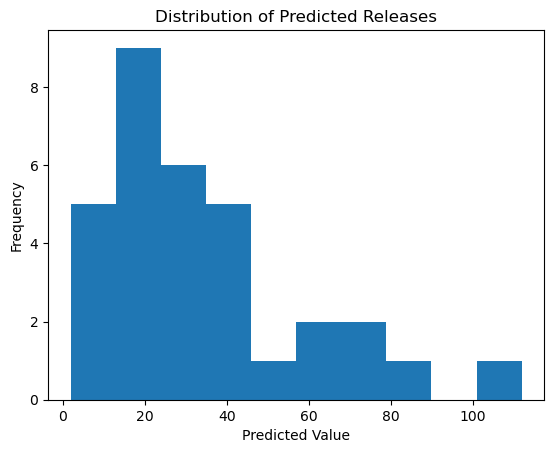

In [32]:
plt.hist(df['2025-26 predicted'], bins=10)
plt.title("Distribution of Predicted Releases")
plt.xlabel("Predicted Value")
plt.ylabel("Frequency")
plt.show()

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


In [38]:
X = df[['2022-23 - Release','2023-24 - Release']]
y = df['2024-25 - Release']
linear = LinearRegression()
linear.fit(X,y)
pred_linear = linear.predict(X)
mae_linear = mean_absolute_error(y, pred_linear)
print("Linear Regression MAE:", mae_linear)
corr_linear = np.corrcoef(y, pred_linear)[0,1]
print("Linear Regression Correlation:", corr_linear)

rf = RandomForestRegressor()
rf.fit(X,y)
pred_rf = rf.predict(X)
mae_rf = mean_absolute_error(y, pred_rf)
print("Random Forest MAE:", mae_rf)
corr_rf = np.corrcoef(y, pred_rf)[0,1]
print("Random Forest Correlation:", corr_rf)

if  mae_linear< mae_rf:
    print("Linear Regression works better for this dataset")
else:
    print("Random Forest works better for this dataset")

Linear Regression MAE: 9.153001885123405
Linear Regression Correlation: 0.637964796064071
Random Forest MAE: 3.4768531250000017
Random Forest Correlation: 0.9590587005115729
Random Forest works better for this dataset


                      State/UT  Cluster
0               Andhra Pradesh        2
1            Arunachal Pradesh        0
2                        Assam        1
3                        Bihar        2
4                  Chhatisgarh        0
5                          Goa        0
6                      Gujarat        2
7                      Haryana        0
8             Himachal Pradesh        0
9                    Jharkhand        0
10                   Karnataka        2
11                      Kerala        0
12              Madhya Pradesh        2
13                 Maharashtra        2
14                     Manipur        0
15                   Meghalaya        0
16                     Mizoram        0
17                    Nagaland        2
18                      Odisha        0
19                      Punjab        0
20                   Rajasthan        2
21                      Sikkim        0
22                  Tamil Nadu        1
23                   Telangana        0


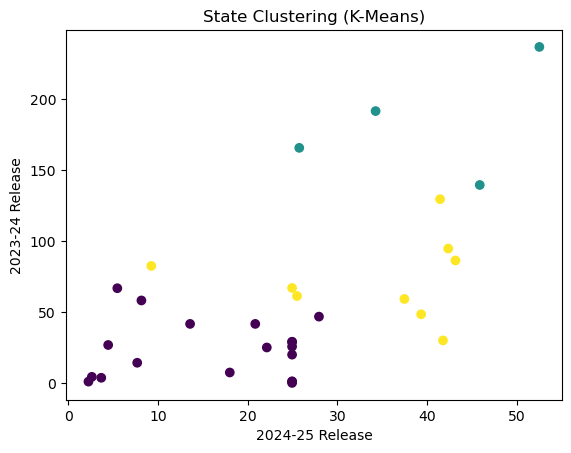

In [44]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[cols])
print(df[['State/UT','Cluster']])

import matplotlib.pyplot as plt
plt.scatter(df['2024-25 - Release'], df['2023-24 - Release'], c=df['Cluster'])
plt.xlabel("2024-25 Release")
plt.ylabel("2023-24 Release")
plt.title("State Clustering (K-Means)")
plt.show()

In [52]:
from sklearn.neighbors import KNeighborsRegressor
years = [[2022],[2023],[2024]]
predictions_knn = []
for index,row in df.iterrows():
    values = [
        row['2022-23 - Release'],
        row['2023-24 - Release'],
        row['2024-25 - Release']
    ]
    model = KNeighborsRegressor(n_neighbors=2)
    model.fit(years, values)
    pred = model.predict([[2025]])
    predictions_knn.append(pred[0])
df['2025-26 KNN'] = predictions_knn
print(df[['State/UT','2025-26 KNN']])

                      State/UT  2025-26 KNN
0               Andhra Pradesh       64.755
1            Arunachal Pradesh       33.150
2                        Assam      144.695
3                        Bihar       43.885
4                  Chhatisgarh       31.235
5                          Goa        1.590
6                      Gujarat       48.345
7                      Haryana       26.905
8             Himachal Pradesh        3.660
9                    Jharkhand       12.695
10                   Karnataka       85.490
11                      Kerala       10.955
12              Madhya Pradesh       45.960
13                 Maharashtra       68.550
14                     Manipur       27.005
15                   Meghalaya       22.455
16                     Mizoram       15.600
17                    Nagaland       45.865
18                      Odisha       37.355
19                      Punjab       25.290
20                   Rajasthan       35.895
21                      Sikkim  

In [54]:
from sklearn.tree import DecisionTreeRegressor
predictions_dt = []
for index,row in df.iterrows():
    values = [
        row['2022-23 - Release'],
        row['2023-24 - Release'],
        row['2024-25 - Release']
    ]
    model = DecisionTreeRegressor(random_state=42)
    model.fit(years, values)
    pred = model.predict([[2025]])
    predictions_dt.append(pred[0])
df['2025-26 DT'] = predictions_dt
print(df[['State/UT','2025-26 DT']])

                      State/UT  2025-26 DT
0               Andhra Pradesh       43.18
1            Arunachal Pradesh        8.14
2                        Assam       52.54
3                        Bihar       39.35
4                  Chhatisgarh       20.84
5                          Goa        2.23
6                      Gujarat       37.48
7                      Haryana       24.95
8             Himachal Pradesh        3.66
9                    Jharkhand       18.00
10                   Karnataka       41.46
11                      Kerala        7.67
12              Madhya Pradesh       24.95
13                 Maharashtra       42.37
14                     Manipur       24.95
15                   Meghalaya       24.95
16                     Mizoram        4.43
17                    Nagaland        9.24
18                      Odisha       27.95
19                      Punjab       24.95
20                   Rajasthan       41.79
21                      Sikkim        5.45
22         

In [56]:
from sklearn.metrics import mean_absolute_error
actual = df['2024-25 - Release']
mae_knn = mean_absolute_error(actual, df['2025-26 KNN'])
mae_dt = mean_absolute_error(actual, df['2025-26 DT'])
print("KNN MAE:", mae_knn)
print("Decision Tree MAE:", mae_dt)

KNN MAE: 19.738750000000003
Decision Tree MAE: 0.0


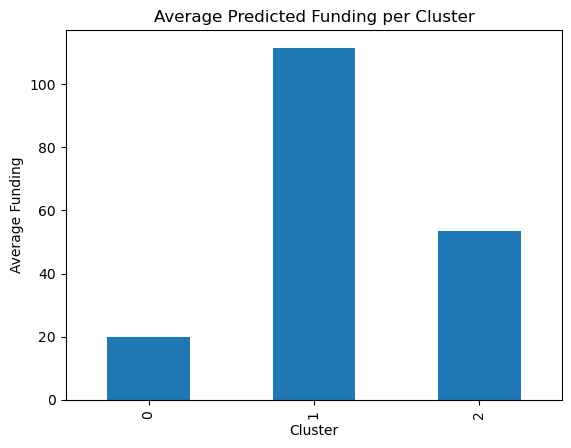

In [58]:
import matplotlib.pyplot as plt
df.groupby('Cluster')['2025-26 KNN'].mean().plot(kind='bar')
plt.title("Average Predicted Funding per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Funding")
plt.show()

In [62]:
mae_values = {
    "LR": mae_linear,
    "RF": mae_rf,
    "KNN": mae_knn,
    "DT": mae_dt
}
best_model = min(mae_values, key=mae_values.get)
print("\nBest Model is:", best_model)


Best Model is: DT


In [64]:
rollup = df.groupby('Category')[[
    '2022-23 - Release',
    '2023-24 - Release',
    '2024-25 - Release',
    '2025-26 predicted'
]].sum()

print(rollup)

                 2022-23 - Release  2023-24 - Release  2024-25 - Release  \
Category                                                                   
State                      1392.94            1829.16             697.64   
Union Territory              68.66               6.46              77.46   

                 2025-26 predicted  
Category                            
State                    1060.5458  
Union Territory            56.4300  


In [66]:
drill = df[df['Category'] == 'State']
print(drill[['State/UT','2025-26 predicted']])

             State/UT  2025-26 predicted
0      Andhra Pradesh            55.8240
1   Arunachal Pradesh            22.7058
2               Assam           111.8709
3               Bihar            41.6623
4         Chhatisgarh            27.8481
5                 Goa             1.9698
6             Gujarat            45.1657
7             Haryana            26.2784
8    Himachal Pradesh             5.1265
9           Jharkhand            15.6726
10          Karnataka            67.5004
11             Kerala            10.5858
12     Madhya Pradesh            38.1443
13        Maharashtra            58.3084
14            Manipur            25.2894
15          Meghalaya            23.9049
16            Mizoram            11.3046
17           Nagaland            30.8695
18             Odisha            32.9879
19             Punjab            25.5492
20          Rajasthan            40.4404
21             Sikkim            23.1407
22         Tamil Nadu            77.5939
23          Tela

In [68]:
slice_data = df[df['Category'] == 'Union Territory']
print(slice_data)

   Sl. No                    State/UT         Category  2022-23 - Release  \
28     30  Andman and Nicobar Islands  Union Territory              32.99   
29     35           Jammu and Kashmir  Union Territory               2.25   
30     37                 Pudducherry  Union Territory               0.43   
31     38                      Ladakh  Union Territory              32.99   

    2023-24 - Release  2024-25 - Release  2025-26 predicted  Cluster  \
28               1.00              24.95            18.4065        0   
29               4.32               2.61             3.0879        0   
30               0.03              24.95            16.4972        0   
31               1.11              24.95            18.4384        0   

    2025-26 KNN  2025-26 DT  
28       12.975       24.95  
29        3.465        2.61  
30       12.490       24.95  
31       13.030       24.95  


In [70]:
dice = df[
    (df['Category'] == 'State') &
    (df['2025-26 predicted'] > 50)
]
print(dice[['State/UT','2025-26 predicted']])

          State/UT  2025-26 predicted
0   Andhra Pradesh            55.8240
2            Assam           111.8709
10       Karnataka            67.5004
13     Maharashtra            58.3084
22      Tamil Nadu            77.5939
25   Uttar Pradesh            84.8994
27     West Bengal            73.5934


In [72]:
pivot = pd.pivot_table(
    df,
    values='2025-26 predicted',
    index='Category',
    aggfunc='mean'
)
print(pivot)

                 2025-26 predicted
Category                          
State                    37.876636
Union Territory          14.107500


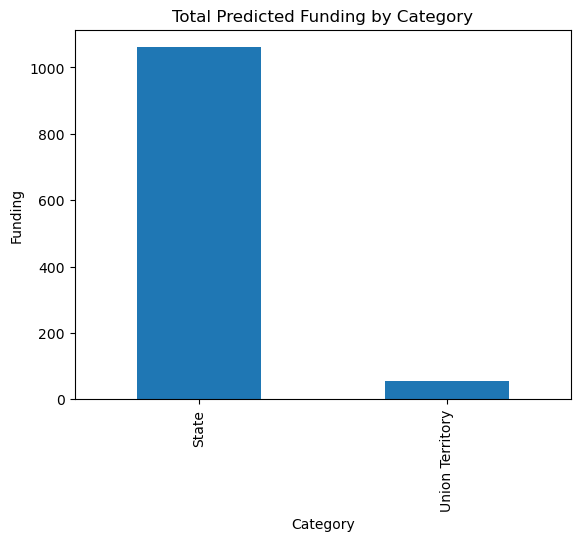

In [74]:
rollup['2025-26 predicted'].plot(kind='bar')
plt.title("Total Predicted Funding by Category")
plt.xlabel("Category")
plt.ylabel("Funding")
plt.show()